In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent 
SRC_DIR = PROJECT_ROOT / "src"

sys.path.append(str(SRC_DIR))

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Connect to DB
con = duckdb.connect("../data/ail_sensory.duckdb")

# Better display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
def show_query(title, query, limit=None):
    print(f"\n=== {title} ===")
    df = con.execute(query).fetchdf()
    
    if limit:
        display(df.head(limit))
    else:
        display(df)
        
    return df

In [4]:
basic_summary = show_query(
    "Basic Dataset Summary",
    """
    SELECT
        COUNT(*) AS total_reviews,
        COUNT(DISTINCT parent_asin) AS unique_products,
        COUNT(DISTINCT asin) AS unique_asins,
        COUNT(DISTINCT user_id) AS unique_users,
        ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT parent_asin), 2) AS avg_reviews_per_product
    FROM joined_reviews
    """
)


=== Basic Dataset Summary ===


,total_reviews,unique_products,unique_asins,unique_users,avg_reviews_per_product
0,2500939,825869,874297,2035490,3.03


In [5]:
schema = show_query(
    "Schema",
    "DESCRIBE joined_reviews"
)


=== Schema ===


,column_name,column_type,null,key,default,extra
0,rating,DOUBLE,YES,None,None,None
1,review_title,VARCHAR,YES,None,None,None
2,review_text,VARCHAR,YES,None,None,None
3,asin,VARCHAR,YES,None,None,None
4,parent_asin,VARCHAR,YES,None,None,None
5,user_id,VARCHAR,YES,None,None,None
6,timestamp,BIGINT,YES,None,None,None
7,helpful_vote,BIGINT,YES,None,None,None
8,verified_purchase,BOOLEAN,YES,None,None,None
9,product_title,VARCHAR,YES,None,None,None



=== Rating Distribution ===


,rating,count
0,1.0,303411
1,2.0,173462
2,3.0,245471
3,4.0,352327
4,5.0,1426268


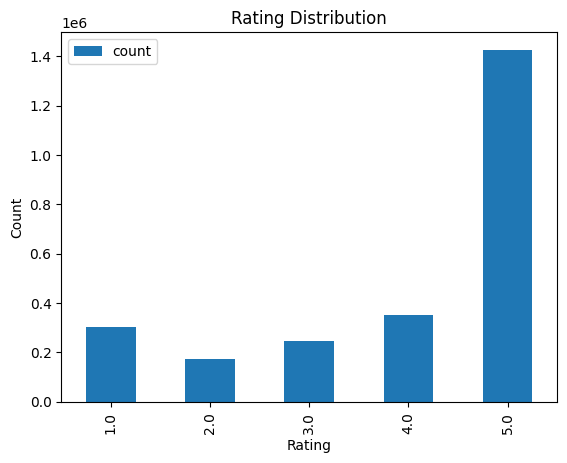

In [6]:
rating_dist = show_query(
    "Rating Distribution",
    """
    SELECT
        rating,
        COUNT(*) AS count
    FROM joined_reviews
    GROUP BY rating
    ORDER BY rating
    """
)

rating_dist.plot(
    x="rating",
    y="count",
    kind="bar",
    title="Rating Distribution"
)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


=== Verified Purchase Distribution ===


,verified_purchase,count
0,False,163237
1,True,2337702


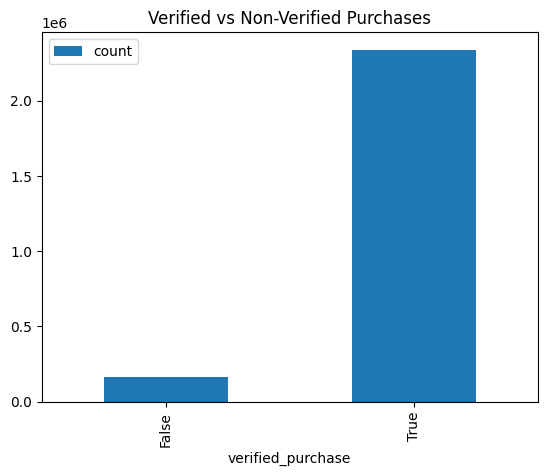

In [7]:
verified = show_query(
    "Verified Purchase Distribution",
    """
    SELECT
        verified_purchase,
        COUNT(*) AS count
    FROM joined_reviews
    GROUP BY verified_purchase
    """
)

verified.plot(
    x="verified_purchase",
    y="count",
    kind="bar",
    title="Verified vs Non-Verified Purchases"
)

plt.show()

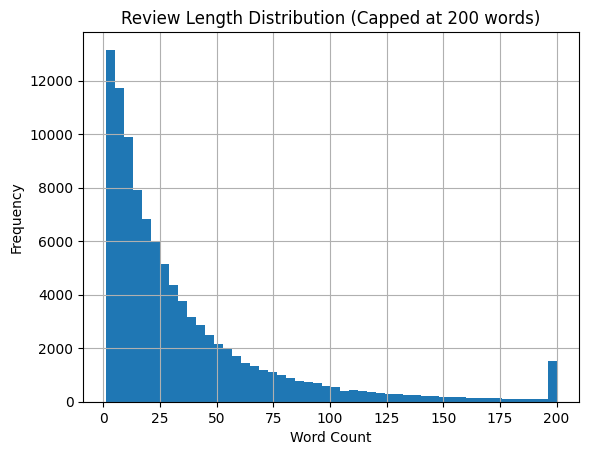

In [8]:
review_lengths = con.execute("""
    SELECT
        ARRAY_LENGTH(
            REGEXP_SPLIT_TO_ARRAY(TRIM(COALESCE(review_text, '')), '\\s+')
        ) AS review_word_length
    FROM joined_reviews
    LIMIT 100000
""").fetchdf()

review_lengths["review_word_length"].clip(upper=200).hist(bins=50)

plt.title("Review Length Distribution (Capped at 200 words)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [9]:
missing = show_query(
    "Missing Data Summary",
    """
    SELECT
        COUNT(*) AS total_rows,
        COUNT(price) AS price_present,
        COUNT(store) AS store_present
    FROM joined_reviews
    """
)


=== Missing Data Summary ===


,total_rows,price_present,store_present
0,2500939,433748,2422267


In [10]:
metadata_quality = show_query(
    "Metadata Quality",
    """
    SELECT
        ROUND(AVG(CASE WHEN price IS NULL THEN 1 ELSE 0 END) * 100, 2) AS price_missing_pct,
        ROUND(AVG(CASE WHEN categories = '[]' THEN 1 ELSE 0 END) * 100, 2) AS categories_empty_pct,
        ROUND(AVG(CASE WHEN description = '[]' THEN 1 ELSE 0 END) * 100, 2) AS description_empty_pct
    FROM joined_reviews
    """
)


=== Metadata Quality ===


,price_missing_pct,categories_empty_pct,description_empty_pct
0,82.66,100.0,87.49



=== Top Stores ===


,store,review_count
0,NELEUS,15432
1,Romwe,10955
2,Casio,9874
3,Nike,8969
4,CHUVORA,8645
5,GRACE KARIN,8539
6,Verdusa,8502
7,Allegra K,8473
8,Disney,8213
9,Floerns,7439


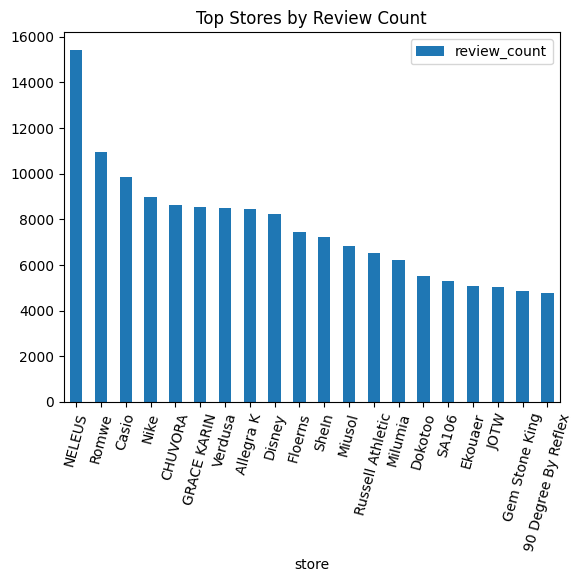

In [11]:
top_stores = show_query(
    "Top Stores",
    """
    SELECT
        store,
        COUNT(*) AS review_count
    FROM joined_reviews
    WHERE store IS NOT NULL
    GROUP BY store
    ORDER BY review_count DESC
    LIMIT 20
    """
)

top_stores.plot(
    x="store",
    y="review_count",
    kind="bar",
    title="Top Stores by Review Count"
)

plt.xticks(rotation=75)
plt.show()

In [12]:
product_counts = show_query(
    "Reviews per Product",
    """
    WITH counts AS (
        SELECT parent_asin, COUNT(*) AS review_count
        FROM joined_reviews
        GROUP BY parent_asin
    )
    SELECT review_count, COUNT(*) AS num_products
    FROM counts
    GROUP BY review_count
    ORDER BY review_count
    LIMIT 50
    """
)


=== Reviews per Product ===


,review_count,num_products
0,1,489854
1,2,143167
2,3,63281
3,4,34320
4,5,21417
5,6,14124
6,7,10304
7,8,7672
8,9,5845
9,10,4583


In [13]:
product_summary = show_query(
    "Product-Level Summary",
    """
    WITH counts AS (
        SELECT parent_asin, COUNT(*) AS review_count
        FROM joined_reviews
        GROUP BY parent_asin
    )
    SELECT
        COUNT(*) AS total_products,
        AVG(review_count) AS avg_reviews,
        MEDIAN(review_count) AS median_reviews,
        SUM(CASE WHEN review_count = 1 THEN 1 ELSE 0 END) AS one_review_products
    FROM counts
    """
)


=== Product-Level Summary ===


,total_products,avg_reviews,median_reviews,one_review_products
0,825869,3.028251,1.0,489854.0


In [14]:
sample = show_query(
    "Sample Rows",
    """
    SELECT
        product_title,
        review_title,
        review_text,
        rating,
        price,
        store
    FROM joined_reviews
    LIMIT 10
    """
)


=== Sample Rows ===


,product_title,review_title,review_text,rating,price,store
0,CHUVORA 925 Sterling Silver Open Celtic Knot C...,Pretty locket,I think this locket is really pretty. The insi...,5.0,30.00,CHUVORA
1,XX-Large Slip Stop Single Tread Slipper Socks ...,A,Great,5.0,20.99,PrimeMed
2,Sterling Silver 3mm Round Cut CZ Tennis Bracel...,Two Stars,One of the stones fell out within the first 2 ...,2.0,NaN,KEZEF
3,VERO MONTE 4 Pairs Womens TRULY No Show Socks ...,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,1.0,NaN,VERO MONTE
4,SA106 Womens Rhinestone Jewel Polarized Lens 6...,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,5.0,12.95,SA106
5,Neck Gaiter for Kids Face Cover Scarf Neck Gai...,Adult friendly; Not for small kids,Works OK for adults and is not at all kid frie...,3.0,NaN,Kranchungel
6,PUMA Men's IT Evotrg Graphic Tee True Blue/Bri...,Five Stars,Great fit,5.0,NaN,PUMA
7,joyliveCY Women Charm Jewerly Rose Gold Plated...,Heavy earrings for size of owls but so darn cute!,Would be five stars but they are just too heav...,4.0,NaN,joyliveCY
8,Twotwowin womens Casual,Bright and summer,What a cute top! Cam wait to wear in warm weat...,5.0,NaN,Twotwowin
9,ULTPEAK Dog Bark Control Anti Bark 50 FT Range...,Scratchy,"Very inexpensive, but too rough and uncomforta...",2.0,NaN,ULTPEAK


## EDA Summary

### Dataset Overview
The dataset contains around 2.5 million reviews across 825K products and ~2.0M users, with an average of about 3 reviews per product. While the dataset is large overall, it is quite sparse at the product level, since many products have very few reviews.

### Product Sparsity
A significant portion of products have limited data: about 59% of products have only one review, and the median number of reviews per product is 1. This suggests that product-level analysis (such as averaging ratings) may be unreliable for most items due to insufficient data.

### Rating Distribution
The rating distribution is strongly skewed toward positive reviews. Around 57% of all reviews are 5-star, and over 70% are either 4 or 5 stars. This indicates a clear positivity bias, which should be considered in any modeling and/or analysis.

### Verified Purchases
Most reviews (93.5%) are from verified purchases, which suggests that the dataset is generally reliable. This could be useful for filtering or weighting reviews based on trustworthiness.

### Review Length
Reviews tend to be short, with a median length of 16 words and about 16% containing fewer than 5 words. This means many reviews may not provide much detailed information, which could limit the effectiveness of text-based analysis.

### Metadata Quality
The available metadata is fairly limited. Key fields such as price are missing in over 80% of cases, while others like categories and description are largely empty or uninformative. This could mean the dataset is better suited for text-driven analysis rather than relying on  product attributes.

### Store Distribution
Review activity is concentrated among a relatively small number of stores. This could introduce some bias toward more popular or high-volume sellers.

---


Overall, the dataset is large and well-integrated but presents several challenges, including product-level sparsity, strong positive rating bias, short review lengths, and limited metadata quality.